In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression


In [2]:
df = pd.read_csv("./data/PRSA_data_2010.1.1-2014.12.31.csv")
df.head()
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  str    
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 4.3 MB


Index(['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES',
       'cbwd', 'Iws', 'Is', 'Ir'],
      dtype='str')

In [3]:
df = df[["PRES","TEMP","pm2.5"]]

In [4]:
df = df.dropna()

In [5]:
df.describe()

,PRES,TEMP,pm2.5
count,41757.000000,41757.000000,41757.000000
mean,1016.442896,12.401561,98.613215
std,10.300733,12.175215,92.050387
min,991.000000,-19.000000,0.000000
25%,1008.000000,2.000000,29.000000
50%,1016.000000,14.000000,72.000000
75%,1025.000000,23.000000,137.000000
max,1046.000000,42.000000,994.000000


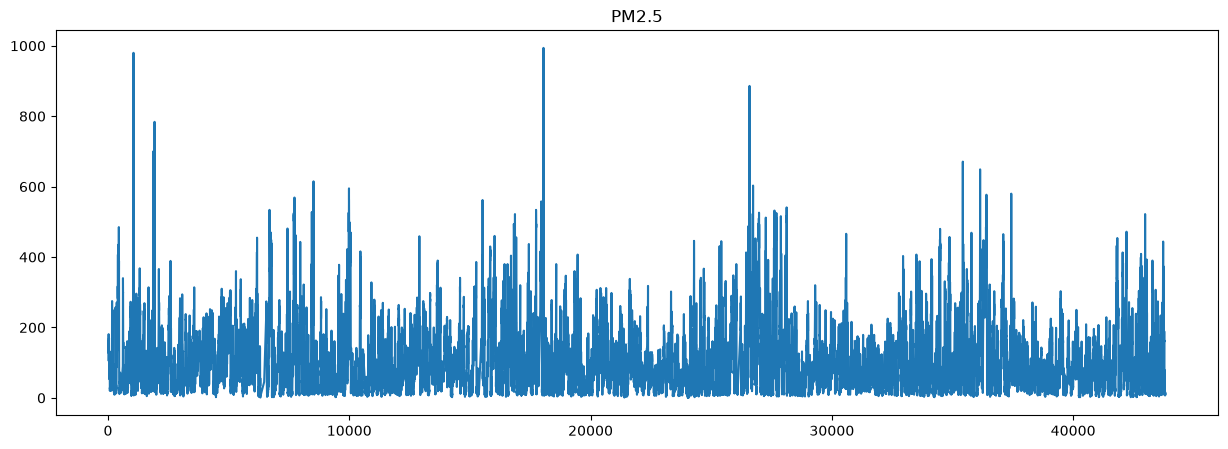

In [6]:
plt.figure(figsize=(15,5))
plt.plot(df["pm2.5"])
plt.title("PM2.5")
plt.show()

In [7]:
df["PM25_NEXT"] = df["pm2.5"].shift(-1)
df["PM25_PREV1"] = df["pm2.5"].shift(1)
df["PM25_PREV2"] = df["pm2.5"].shift(2)
df["PM25_PREV3"] = df["pm2.5"].shift(3)


In [8]:
df = df.dropna()

In [9]:
df.head()

,PRES,TEMP,pm2.5,PM25_NEXT,PM25_PREV1,PM25_PREV2,PM25_PREV3
27,1022.0,-5.0,181.0,138.0,159.0,148.0,129.0
28,1022.0,-5.0,138.0,109.0,181.0,159.0,148.0
29,1022.0,-6.0,109.0,105.0,138.0,181.0,159.0
30,1023.0,-6.0,105.0,124.0,109.0,138.0,181.0
31,1024.0,-5.0,124.0,120.0,105.0,109.0,138.0


In [11]:
X = df[
    [
    "pm2.5",
    "PM25_PREV1",
    "PM25_PREV2",
    "PM25_PREV3",
    "TEMP",
    "PRES",
]
]

In [12]:
y = df["PM25_NEXT"]

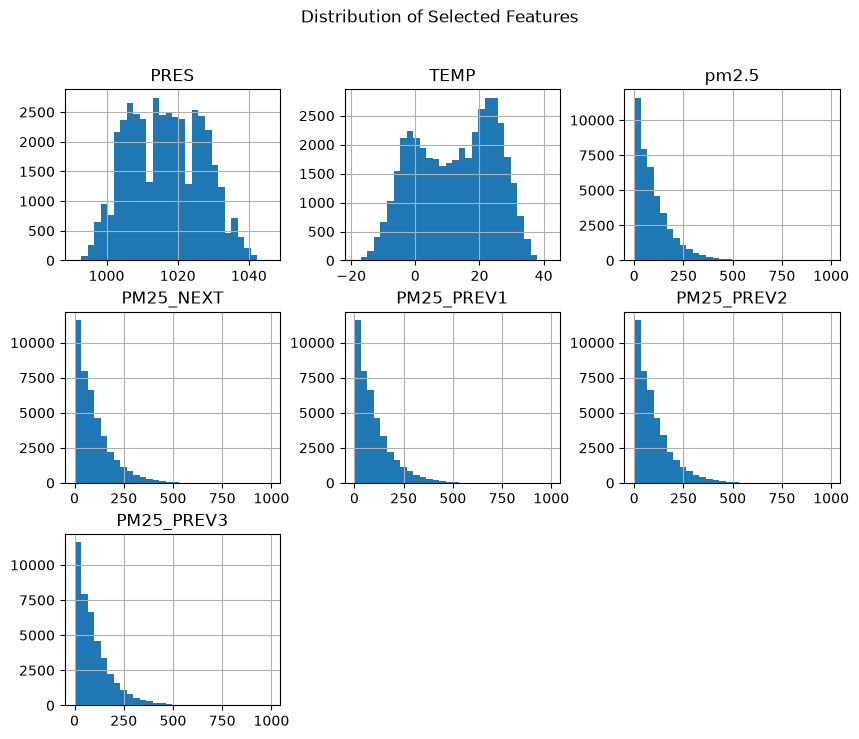

In [13]:
df.hist(figsize=(10, 8), bins=30)
plt.suptitle("Distribution of Selected Features")
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = LinearRegression()

In [16]:
model.fit(X_train, y_train)
print(model.intercept_)
for name,coef in zip(X.columns,model.coef_):
    print(name, coef)

111.33985862078649
pm2.5 1.1395996518578853
PM25_PREV1 -0.2218490063078467
PM25_PREV2 0.0541507123667482
PM25_PREV3 -0.015495787648127436
TEMP -0.10026138040716726
PRES -0.1040735814839828


In [17]:
y_pred = model.predict(X_test)


In [18]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE",mae)
print("RMSE",rmse)
print("R2",r2)

MAE 12.943626500800077
RMSE 23.518444415363035
R2 0.9339776108186009


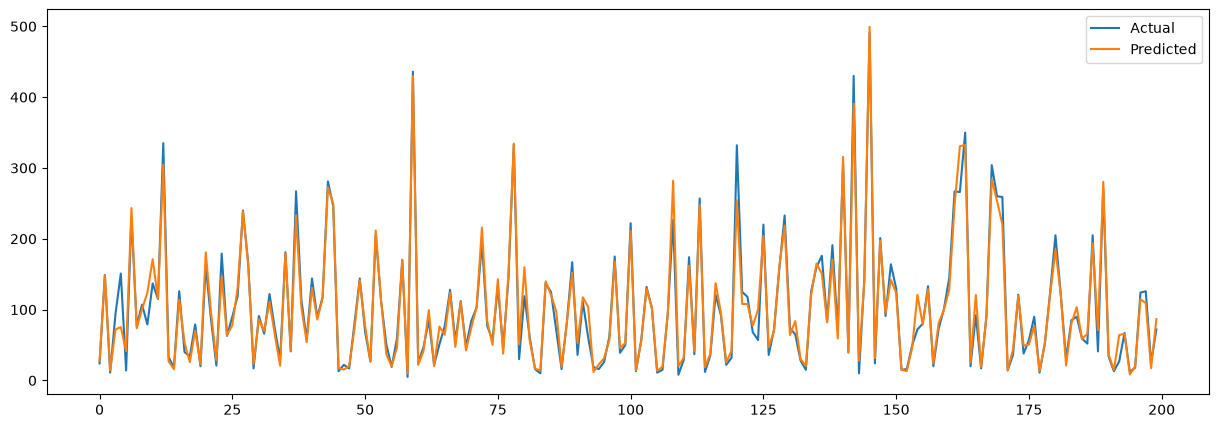

In [19]:
plt.figure(figsize=(15,5))
plt.plot(y_test.values[:200],label="Actual")
plt.plot(y_pred[:200],label="Predicted")
plt.legend()
plt.show()
